**ITESO - Instituto Tecnológico y de Estudios Superiores de Occidente**

---

Alejandro Fernández Vázquez

Andrea Lizeth Arevalo Solis

Arantxa Angulo Flores

# <span style="color:red">Boston Housing Projects - Normalización y Selección de Variables</span>


En este cuaderno preparamos los datos limpios para el modelado.
Aplicamos normalización a las variables numéricas y analizamos
cuáles variables son más relevantes para predecir el precio
de las viviendas (MEDV).

Importación de  librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

Carga y configuración de los datos 

In [3]:
with open('../params.yaml', 'r') as f:
    params = yaml.safe_load(f)

df = pd.read_csv('../data/processed/housing_clean.csv')

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 506
Columnas: 14


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### <span style="color:orange">Normalización:</span>

Las variables del dataset tienen escalas muy diferentes:

- **TAX** va de ~187 a ~711
- **NOX** va de ~0.38 a ~0.87
- **CHAS** es binaria (0 o 1)

Sin normalización, variables con rangos grandes dominarían
artificialmente los modelos basados en distancias o gradientes.

**Método elegido: StandardScaler (Z-score)**

Transforma cada variable para que tenga media = 0 y
desviación estándar = 1.

**Fórmula:**  z = (x - μ) / σ

**Variables excluidas del escalado:**
- `CHAS`: es binaria, escalar no tiene sentido semántico
- `MEDV`: es nuestra variable objetivo, no se transforma

In [4]:
exclude = params['normalization']['exclude_columns']
cols_to_scale = [c for c in df.columns if c not in exclude]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"Columnas escaladas: {cols_to_scale}")
print(f"Columnas excluidas: {exclude}")
df_scaled.head()

Columnas escaladas: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Columnas excluidas: ['CHAS', 'MEDV']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.670290,0.918420,-1.287909,0,-0.144217,0.475982,-0.120013,0.148015,-0.982843,-0.666608,-1.477181,0.786988,-1.088749,24.0
1,-0.663949,-0.579471,-0.593381,0,-0.740262,0.231390,0.367166,0.572202,-0.867883,-0.987329,-0.309941,0.786988,-0.495302,21.6
2,-0.663955,-0.579471,-0.593381,0,-0.740262,1.444822,-0.265812,0.572202,-0.867883,-0.987329,-0.309941,0.573183,-1.224272,34.7
3,-0.662420,-0.579471,-1.306878,0,-0.835284,1.147817,-0.809889,1.101820,-0.752922,-1.106115,0.110265,0.667741,-1.379766,33.4
4,-0.651339,-0.579471,-1.306878,0,-0.835284,1.384468,-0.511180,1.101820,-0.752922,-1.106115,0.110265,0.786988,-1.038819,36.2


In [5]:
print("Estadísticas post-normalización (columnas escaladas):")
df_scaled[cols_to_scale].describe().round(4)

Estadísticas post-normalización (columnas escaladas):


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000
mean,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000
std,1.0010,1.0010,1.0010,1.0010,1.0010,1.0010,1.0010,1.0010,1.0010,1.0010,1.0010,1.0010
min,-0.6703,-0.5795,-1.5578,-1.4659,-2.3773,-2.3354,-1.2837,-0.9828,-1.3140,-2.4577,-1.9864,-1.5524
25%,-0.6474,-0.5795,-0.8677,-0.9130,-0.6191,-0.8374,-0.8143,-0.6380,-0.7676,-0.4967,-0.3436,-0.8077
50%,-0.5947,-0.5795,-0.2111,-0.1442,-0.1061,0.3174,-0.2788,-0.5230,-0.4647,0.2737,0.5002,-0.1786
75%,0.4387,0.4607,1.0160,0.5987,0.5530,0.9068,0.6792,1.6612,1.5309,0.8106,0.7515,0.6196
max,2.0678,2.0210,2.4226,2.7323,2.3112,1.1175,2.9196,1.6612,1.7982,1.6510,0.7870,2.7605


### <span style="color:orange">Análisis de ecorrelación:</span> 

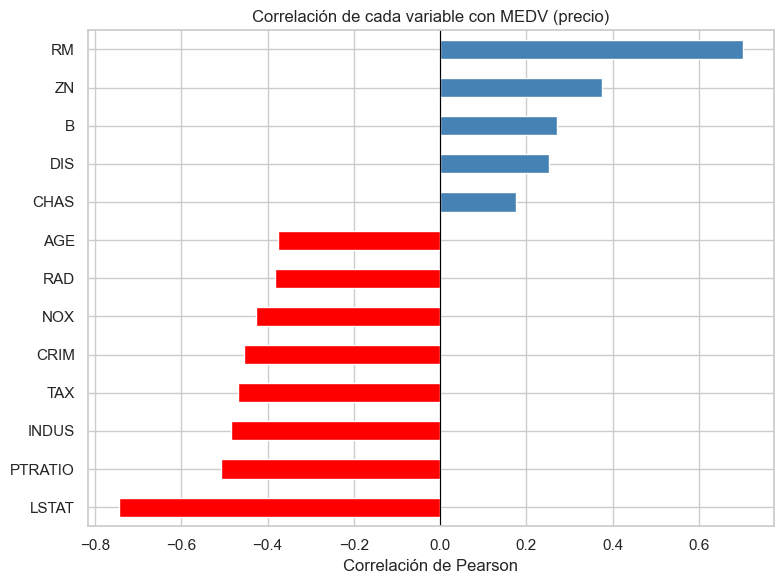


Correlaciones ordenadas:
LSTAT     -0.744
PTRATIO   -0.507
INDUS     -0.484
TAX       -0.469
CRIM      -0.454
NOX       -0.427
RAD       -0.382
AGE       -0.377
CHAS       0.175
DIS        0.253
B          0.271
ZN         0.375
RM         0.702
Name: MEDV, dtype: float64


In [6]:
correlaciones = df_scaled.corr()['MEDV'].drop('MEDV').sort_values()

plt.figure(figsize=(8, 6))
correlaciones.plot(kind='barh', color=['red' if c < 0 else 'steelblue' for c in correlaciones])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de cada variable con MEDV (precio)')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print("\nCorrelaciones ordenadas:")
print(correlaciones.round(3))

## Interpretación

Las variables con mayor relación lineal con el precio son:

| Variable | Correlación | Interpretación |
|----------|-------------|----------------|
| **LSTAT** | −0.744 | A mayor % de población de bajos ingresos, menor precio |
| **RM**    | +0.702 | A mayor número de habitaciones, mayor precio |
| **PTRATIO** | −0.507 | A mayor ratio alumno/maestro (peor educación), menor precio |
| **INDUS** | −0.484 | A mayor proporción industrial, menor precio |

Variables como `CHAS` (binaria) y `DIS` tienen correlación baja, pero el modelo las incluirá para dejar que los datos decidan.